In [25]:
import pandas as pd
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
load_dotenv()

True

In [4]:
# carregando dataset de players
path = os.getenv('DATASETS_PATH')
df = pd.read_csv(path + '/appearances.csv')
df.head()

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,76,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


In [ ]:
# vendo informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1889406 entries, 0 to 1889405
Data columns (total 13 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   appearance_id           object
 1   game_id                 int64 
 2   player_id               int64 
 3   player_club_id          int64 
 4   player_current_club_id  int64 
 5   date                    object
 6   player_name             object
 7   competition_id          object
 8   yellow_cards            int64 
 9   red_cards               int64 
 10  goals                   int64 
 11  assists                 int64 
 12  minutes_played          int64 
dtypes: int64(9), object(4)
memory usage: 187.4+ MB


In [ ]:
# vendo distribuição dos minutos jogados
df['minutes_played'].value_counts()

minutes_played
90     989331
45      76274
1       30210
78      13257
77      13185
        ...  
107        18
92         18
0           4
135         2
148         1
Name: count, Length: 123, dtype: int64

In [ ]:
# distribuição de jogos
df['goals'].value_counts()

goals
0    1728115
1     144524
2      14885
3       1696
4        162
5         23
6          1
Name: count, dtype: int64

In [ ]:
# distribuição de assistencias
df['assists'].value_counts()

assists
0    1757819
1     122040
2       8918
3        588
4         38
5          2
6          1
Name: count, dtype: int64

In [ ]:
# Contando a quantidade de aparições do messi na qual ele marcou gols
df[(df['player_name'] == 'Lionel Messi') & (df['goals'] > 0)]

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
8135,2244378_28003,2244378,28003,131,69261,2012-08-19,Lionel Messi,ES1,0,0,2,0,90
8929,2244388_28003,2244388,28003,131,69261,2012-08-22,Lionel Messi,SUC,0,0,1,0,90
11912,2242828_28003,2242828,28003,131,69261,2012-08-26,Lionel Messi,ES1,0,0,2,0,90
12883,2244389_28003,2244389,28003,131,69261,2012-08-29,Lionel Messi,SUC,0,0,1,0,90
18056,2242910_28003,2242910,28003,131,69261,2012-09-15,Lionel Messi,ES1,0,0,2,0,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441552,3840442_28003,3840442,28003,583,69261,2023-05-27,Lionel Messi,FR1,0,0,1,0,90
1736882,4506833_28003,4506833,28003,69261,69261,2025-06-19,Lionel Messi,KLUB,0,0,1,0,90
1887905,4776617_28003,4776617,28003,3437,69261,2026-06-17,Lionel Messi,FIWC,0,0,3,0,80
1888605,4776641_28003,4776641,28003,3437,69261,2026-06-22,Lionel Messi,FIWC,0,0,2,0,90


Se existem apenas 303 aparições do messi em que ele marcou gols nesse dataset, então está incompleto, pois ele marcou gols em mais de 600 partidas diferentes (entre o periodo que o dataset deveria cobrir, que é de 2000 até os dias de hoje)

In [29]:
# parse da data e cobertura temporal das aparições
df['date'] = pd.to_datetime(df['date'])
print("Primeiro registro:", df['date'].min())
print("Último registro:", df['date'].max())

Primeiro registro: 2012-07-03 00:00:00
Último registro: 2026-06-28 00:00:00


In [22]:
# quantas ligas diferentes tem
df['competition_id'].value_counts().count()

48

In [24]:
# vendo as diferentes ligas
df['competition_id'].value_counts()

competition_id
IT1     154999
ES1     153675
GB1     149685
FR1     143246
TR1     132007
L1      124511
NL1     119807
PO1     119627
BE1     100778
RU1      95218
GR1      87499
SC1      80954
UKR1     75861
DK1      65161
EL       55676
CL       49470
ELQ      19334
CDR      17310
GRP      15400
RUP      14691
FAC      13934
DFB      11338
CIT      11284
NLP      10523
CLQ      10483
POCP      9757
ECLQ      9584
DKP       9546
SFA       7388
UKRP      6542
CGB       2285
FIWC      2053
KLUB      1808
SUC        973
POBE       907
EJPL       905
AFCN       776
SCI        597
GBCS       415
DFL        411
USC        407
RUSS       406
FRCH       401
POSU       393
BESC       372
NLSC       368
BPO4       366
UKRS       275
Name: count, dtype: int64

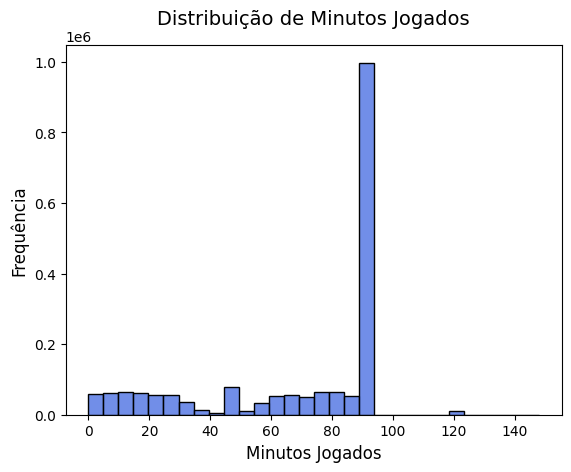

In [26]:
# histograma simples com a distribuição de minutos jogados
sns.histplot(data=df, x='minutes_played', bins=30, color='royalblue')

# Customização de títulos e eixos
plt.title('Distribuição de Minutos Jogados', fontsize=14, pad=15)
plt.xlabel('Minutos Jogados', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Exibe o gráfico e salva
plot_path = os.getenv('PLOTS_PATH')
plt.savefig(plot_path + '/distribution_minutes_played.png', dpi=300, bbox_inches='tight')
plt.show()


In [27]:
# vendo quantos jogadores únicos aparecem no dataset
df['player_id'].nunique()

28942

In [30]:
# vendo a evolução/distribuição da quantidade de aparições por ano
df['year'] = df['date'].dt.year
df['year'].value_counts().sort_index()

year
2012     71688
2013    129862
2014    125776
2015    132338
2016    131075
2017    135103
2018    126996
2019    128672
2020    114160
2021    147383
2022    129335
2023    150698
2024    145640
2025    149521
2026     71159
Name: count, dtype: int64